# Random Forest Source-Zone Workflow

**Updated 2026-06-05:** aligned burn severity is used unchanged, PDP features are configurable, and a logistic-regression relationship section is included.


Dedicated notebook for source-zone random forest experiments.

This notebook keeps the workflow separate from the physical PCI/source-area notebook:

- Build a binary ML target from `G`, channel cutoff, and DoD erosion.
- Load terrain, soil, burn, and optional GEE change features such as `et_diff` and `ndvi_diff`.
- Train/test with held-out polygons.
- Tune the random forest only on training polygons.
- Evaluate on held-out polygons.
- Plot feature importance and partial dependence.
- Export probability/class rasters to Windows Downloads.

In [3]:
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

src_path = Path("/mnt/c/Users/amehedi/Downloads/post-pre_COREG_BIAS_ASPECT_o1_a90_dDEM.tif")
ref_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/topographic__elevation.tif")
out_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif")

nodata = -9999.0

with rasterio.open(ref_path) as ref, rasterio.open(src_path) as src:
    ref_arr = ref.read(1)
    ref_invalid = ~np.isfinite(ref_arr)
    if ref.nodata is not None:
        ref_invalid |= np.isclose(ref_arr, ref.nodata)

    aligned = np.full((ref.height, ref.width), nodata, dtype="float32")

    reproject(
        source=rasterio.band(src, 1),
        destination=aligned,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=ref.transform,
        dst_crs=ref.crs,
        dst_nodata=nodata,
        resampling=Resampling.bilinear,
    )

    aligned[ref_invalid] = nodata

    profile = ref.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=nodata,
        compress="deflate",
    )

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(aligned, 1)

print("saved:", out_path)

saved: /mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif


## 1. Setup

In [4]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Find repo root whether notebook is run from repo root or notebooks/.
REPO = Path.cwd()
if not (REPO / 'src').exists():
    REPO = REPO.parent
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

from pci_source_zones.config import load_config, output_path, resolve_path
from pci_source_zones.inputs import read_raster

cfg = load_config(REPO / 'config' / 'montecito.yaml')

print('repo:', REPO)
print('site:', cfg.get('site'))

repo: /home/abdullah/pci-source-zones
site: montecito


## 2. Editable Inputs

Keep all experiment controls here. `FEATURE_FILES` are required unless `SKIP_MISSING_FEATURES = True`.

In [5]:
# --------------------
# Paths
# --------------------
DATA = Path('/mnt/c/Users/amehedi/Downloads/thomas')
GEE_DATA = Path('/mnt/c/Users/amehedi/Downloads/gee_lai_ndvi_et')
OUT = Path('/mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest')
OUT.mkdir(parents=True, exist_ok=True)

POLYGON_PATH = Path('/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg')
POLYGON_ID_FIELD = 'poly_id'
TRAIN_POLY_IDS = [3]
TEST_POLY_IDS = [4]

# --------------------
# Target controls
# --------------------
C_SOURCE = 20
C_CHANNEL = 120
DOD_THRESHOLD = -0.277
TARGET_NODATA = 255

# --------------------
# RF controls
# --------------------
RANDOM_SEED = 42
NEGATIVE_TO_POSITIVE_RATIO = 3
PROB_THRESHOLD = 0.50

# If True, missing feature files raise an error. If False, they are skipped with a message.
SKIP_MISSING_FEATURES = True

# Update GEE filenames after running notebooks/gee_lai_ndvi_et_workflow.ipynb.
FEATURE_FILES = {
    # Keep burn severity values unchanged. This raster is only clipped/aligned to the DEM grid.
    'burn_severity': DATA / 'burn_severity_montecito_aoi_aligned.tif',
    'soil_texture': DATA / 'soil__texture.tif',
    'soil_thickness': DATA / 'soil__thickness.tif',
    'soil_density': DATA / 'soil__density.tif',
    'sand_total': DATA / 'sand__total.tif',
    'silt_total': DATA / 'silt__total.tif',
    'clay_total': DATA / 'clay__total.tif',
    'porosity': DATA / 'porosity.tif',
    'pH': DATA / 'pH.tif',
    'field_capacity': DATA / 'field__capacity.tif',
    'saturated_water_content': DATA / 'saturated__water_content.tif',
    'soil_transmissivity': DATA / 'soil__transmissivity.tif',
    'saturated_hydraulic_conductivity': DATA / 'soil__saturated_hydraulic_conductivity.tif',
    'landcover': DATA / 'landcover.tif',

    # GEE change layers. Use aligned rasters, not raw downloads.
    'et_diff': GEE_DATA / 'ET_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif',
    'ndvi_diff': GEE_DATA / 'NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif',
}

print('output folder:', OUT)
print('feature count configured:', len(FEATURE_FILES))

output folder: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest
feature count configured: 16


## 3. Helpers

In [6]:
def check_same_grid(path, reference_profile):
    with rasterio.open(path) as src:
        same_shape = (src.height, src.width) == (
            reference_profile['height'],
            reference_profile['width'],
        )
        same_crs = src.crs == reference_profile['crs']
        same_transform = src.transform.almost_equals(reference_profile['transform'])

    if not (same_shape and same_crs and same_transform):
        raise ValueError(
            f'Raster is not aligned with reference grid: {path}\n'
            f'same_shape={same_shape}, same_crs={same_crs}, same_transform={same_transform}'
        )

def write_uint8_raster(path, array, profile, nodata=255):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    meta = profile.copy()
    meta.update(driver='GTiff', count=1, dtype='uint8', nodata=nodata, compress='deflate')
    if not meta.get('tiled', False):
        meta.pop('blockxsize', None)
        meta.pop('blockysize', None)
    with rasterio.open(path, 'w', **meta) as dst:
        dst.write(np.asarray(array, dtype='uint8'), 1)
    return path

def write_float_raster(path, array, profile, nodata=-9999.0):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    data = np.asarray(array, dtype='float32')
    write_data = np.where(np.isfinite(data), data, nodata).astype('float32')
    meta = profile.copy()
    meta.update(driver='GTiff', count=1, dtype='float32', nodata=nodata, compress='deflate')
    if not meta.get('tiled', False):
        meta.pop('blockxsize', None)
        meta.pop('blockysize', None)
    with rasterio.open(path, 'w', **meta) as dst:
        dst.write(write_data, 1)
    return path

def safe_feature_name(name):
    return str(name).replace(' ', '_').replace('/', '_')

def print_class_counts(label, y):
    print(
        label,
        'cells:', len(y),
        'positive:', int(np.sum(y == 1)),
        'negative:', int(np.sum(y == 0)),
    )

## 4. Build And Save The ML Target

`1` means source candidate. `0` means valid non-source. `255` is nodata.

In [7]:
S, profile = read_raster(output_path(cfg, 'slope', 'slope.tif'))
a, _ = read_raster(output_path(cfg, 'specific_catchment_area', 'specific_catchment_area.tif'))
G, _ = read_raster(output_path(cfg, 'topographic_driving_index', 'topographic_driving_index.tif'))
dem_diff, _ = read_raster("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif")

cell_size = abs(float(profile['transform'].a))
DA = a * cell_size

target_valid = (
    np.isfinite(S) &
    np.isfinite(a) &
    np.isfinite(DA) &
    np.isfinite(G) &
    np.isfinite(dem_diff) &
    (S > 0) &
    (DA > 0)
)

source = (
    target_valid &
    (G >= C_SOURCE) &
    (G < C_CHANNEL) &
    (dem_diff < DOD_THRESHOLD)
)

target = np.full(G.shape, TARGET_NODATA, dtype='uint8')
target[target_valid] = 0
target[source] = 1

target_path = OUT / f'ml_target_C{C_SOURCE}_lt_channel_C{C_CHANNEL}_dod_lt_minus_0p277_binary.tif'
write_uint8_raster(target_path, target, profile, nodata=TARGET_NODATA)

Y_raw = np.where(target == TARGET_NODATA, np.nan, target.astype('float32'))
Y = (Y_raw == 1).astype('uint8')

print('saved target:', target_path)
print('valid non-source 0:', int(np.sum(target == 0)))
print('source 1:', int(np.sum(target == 1)))
print('nodata 255:', int(np.sum(target == TARGET_NODATA)))

saved target: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/ml_target_C20_lt_channel_C120_dod_lt_minus_0p277_binary.tif
valid non-source 0: 505607
source 1: 22875
nodata 255: 69378


## 5. Load Features

Terrain features are added directly from the PCI rasters. File-based features are checked against the target grid.

In [ ]:
# --------------------
# Build X and y from selected features
# --------------------

SELECTED_FEATURES = [
    "slope",
    # "specific_area",
    "drainage_area",
    # "G",
    "burn_severity",
    "soil_texture",
    "soil_thickness",
    "soil_density",
    "sand_total",
    "silt_total",
    "clay_total",
    "porosity",
    # "pH",
    "field_capacity",
    "saturated_water_content",
    "soil_transmissivity",
    "saturated_hydraulic_conductivity",
    "landcover",
    "et_diff",
    "ndvi_diff",
]

BASE_FEATURES = {
    "slope": S,
    "specific_area": a,
    "drainage_area": DA,
    "G": G,
}

FEATURE_FILES = {
    "burn_severity": "/mnt/c/Users/amehedi/Downloads/thomas/burn_severity_montecito_aoi_aligned.tif",
    "soil_texture": "/mnt/c/Users/amehedi/Downloads/thomas/soil__texture.tif",
    "soil_thickness": "/mnt/c/Users/amehedi/Downloads/thomas/soil__thickness.tif",
    "soil_density": "/mnt/c/Users/amehedi/Downloads/thomas/soil__density.tif",
    "sand_total": "/mnt/c/Users/amehedi/Downloads/thomas/sand__total.tif",
    "silt_total": "/mnt/c/Users/amehedi/Downloads/thomas/silt__total.tif",
    "clay_total": "/mnt/c/Users/amehedi/Downloads/thomas/clay__total.tif",
    "porosity": "/mnt/c/Users/amehedi/Downloads/thomas/porosity.tif",
    "pH": "/mnt/c/Users/amehedi/Downloads/thomas/pH.tif",
    "field_capacity": "/mnt/c/Users/amehedi/Downloads/thomas/field__capacity.tif",
    "saturated_water_content": "/mnt/c/Users/amehedi/Downloads/thomas/saturated__water_content.tif",
    "soil_transmissivity": "/mnt/c/Users/amehedi/Downloads/thomas/soil__transmissivity.tif",
    "saturated_hydraulic_conductivity": "/mnt/c/Users/amehedi/Downloads/thomas/soil__saturated_hydraulic_conductivity.tif",
    "landcover": "/mnt/c/Users/amehedi/Downloads/thomas/landcover.tif",
    "et_diff": "/mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/ET_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif",
    "ndvi_diff": "/mnt/c/Users/amehedi/Downloads/thomas/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif",
}

features = {}

for name in SELECTED_FEATURES:
    if name in BASE_FEATURES:
        features[name] = BASE_FEATURES[name]
    else:
        arr, _ = read_raster(FEATURE_FILES[name])
        features[name] = arr

valid = np.isfinite(Y_raw)

for arr in features.values():
    valid &= np.isfinite(arr)

X = pd.DataFrame({
    name: arr[valid]
    for name, arr in features.items()
})

y = Y[valid]

print("X features:", list(X.columns))
print("X shape:", X.shape)
print("positive:", int(y.sum()))
print("negative:", int((y == 0).sum()))

X.head()

X features: ['slope', 'drainage_area', 'burn_severity', 'soil_texture', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'soil_transmissivity', 'saturated_hydraulic_conductivity', 'landcover', 'et_diff', 'ndvi_diff']
X shape: (516433, 17)
positive: 22663
negative: 493770


,slope,drainage_area,burn_severity,soil_texture,soil_thickness,soil_density,sand_total,silt_total,clay_total,porosity,field_capacity,saturated_water_content,soil_transmissivity,saturated_hydraulic_conductivity,landcover,et_diff,ndvi_diff
0,2.273737e-14,300.0,0.0,3.0,37.0,2902.654785,57.0,25.0,17.0,0.435,0.249379,0.377354,1.471184,3.976172,43.0,2.124098,-0.022619
1,2.273737e-14,600.0,0.0,3.0,37.0,2902.654785,57.0,25.0,17.0,0.435,0.249379,0.377354,1.467672,3.966680,43.0,2.220644,-0.022645
2,2.273737e-14,1000.0,0.0,3.0,38.0,2902.654785,57.0,25.0,18.0,0.435,0.249379,0.377627,1.420066,3.737016,43.0,2.317190,-0.022671
3,2.273737e-14,1500.0,0.0,3.0,38.0,2920.354004,57.0,25.0,18.0,0.435,0.249379,0.374805,1.420066,3.737016,43.0,2.195271,-0.028909
4,2.273737e-14,2100.0,0.0,3.0,37.0,2920.354004,57.0,25.0,18.0,0.435,0.249379,0.374805,1.371123,3.705739,43.0,1.992476,-0.036365


## 6. Quick Random Split Baseline

This is only a quick baseline. The polygon holdout below is the better spatial test.

In [13]:
pos = np.where(y == 1)[0]
neg = np.where(y == 0)[0]

rng = np.random.default_rng(RANDOM_SEED)
neg_sample = rng.choice(
    neg,
    size=min(len(neg), len(pos) * NEGATIVE_TO_POSITIVE_RATIO),
    replace=False,
)
idx = np.concatenate([pos, neg_sample])
rng.shuffle(idx)

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X.iloc[idx],
    y[idx],
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y[idx],
)

rf_random = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    n_jobs=-1,
)
rf_random.fit(X_train_rand, y_train_rand)
pred_rand = rf_random.predict(X_test_rand)

print_class_counts('random train', y_train_rand)
print_class_counts('random test', y_test_rand)
print(confusion_matrix(y_test_rand, pred_rand))
print(classification_report(y_test_rand, pred_rand, zero_division=0))

random train cells: 63456 positive: 15864 negative: 47592
random test cells: 27196 positive: 6799 negative: 20397
[[18984  1413]
 [ 1460  5339]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     20397
           1       0.79      0.79      0.79      6799

    accuracy                           0.89     27196
   macro avg       0.86      0.86      0.86     27196
weighted avg       0.89      0.89      0.89     27196



saved probability raster: /mnt/c/Users/amehedi/Downloads/source_area_workflow/rf_random_source_probability.tif
saved binary class raster: /mnt/c/Users/amehedi/Downloads/source_area_workflow/rf_random_source_class_p0p5.tif
predicted source cells: 53188


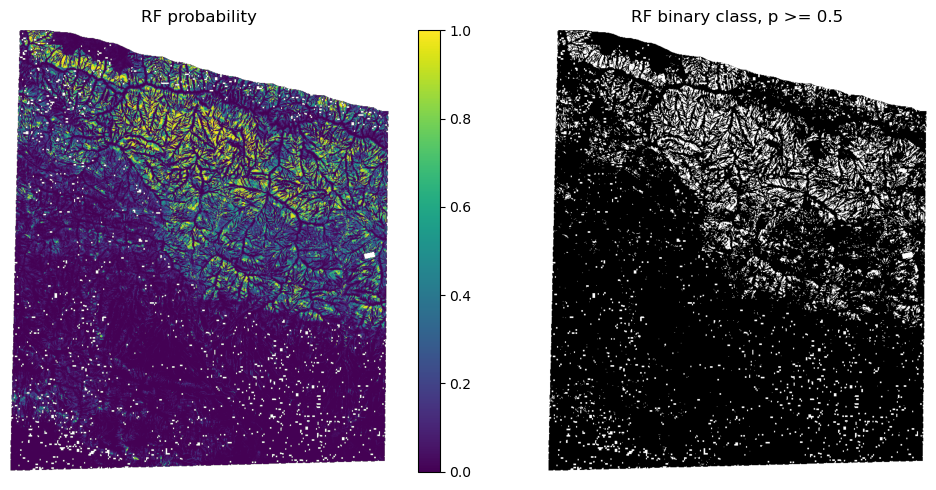

In [15]:
# probability threshold for binary map
PROB_THRESHOLD = 0.5

# output folder
OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow")
OUT.mkdir(parents=True, exist_ok=True)

# predict probability for every valid raster cell
X_full = pd.DataFrame({name: arr[valid] for name, arr in features.items()})

prob_values = rf_random.predict_proba(X_full)[:, 1].astype("float32")

# make probability raster
prob_map = np.full(Y.shape, np.nan, dtype="float32")
prob_map[valid] = prob_values

# make binary class raster
class_map = np.full(Y.shape, 255, dtype="uint8")   # 255 = nodata
class_map[valid] = (prob_map[valid] >= PROB_THRESHOLD).astype("uint8")

# save rasters
prob_path = OUT / "rf_random_source_probability.tif"
class_path = OUT / f"rf_random_source_class_p{str(PROB_THRESHOLD).replace('.', 'p')}.tif"

write_float_raster(prob_path, prob_map, profile)
write_uint8_raster(class_path, class_map, profile, nodata=255)

print("saved probability raster:", prob_path)
print("saved binary class raster:", class_path)
print("predicted source cells:", int(np.sum(class_map == 1)))

# quick plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(prob_map, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("RF probability")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(np.where(class_map == 255, np.nan, class_map), cmap="gray")
axes[1].set_title(f"RF binary class, p >= {PROB_THRESHOLD}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

saved probability raster without channels: /mnt/c/Users/amehedi/Downloads/source_area_workflow/rf_random_source_probability_no_channels_Glt120.tif
saved binary class raster without channels: /mnt/c/Users/amehedi/Downloads/source_area_workflow/rf_random_source_class_no_channels_Glt120_p0p5.tif
source cells after removing channels: 52326


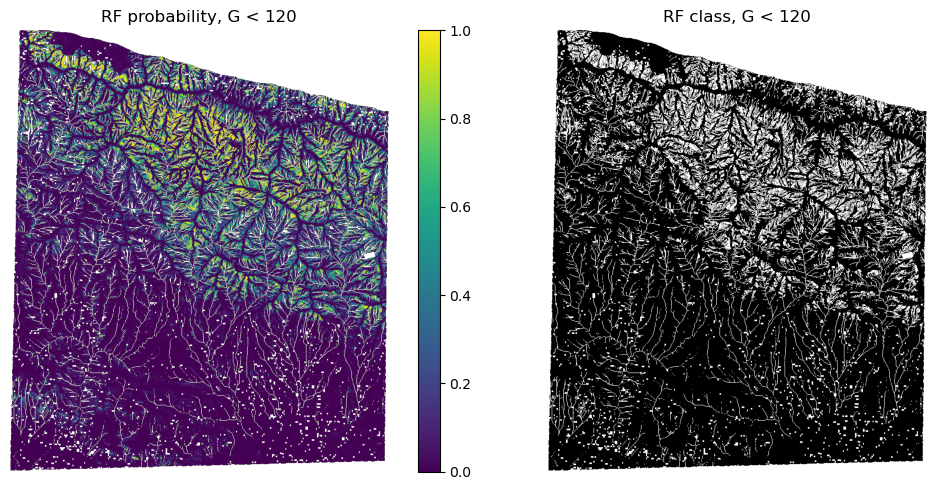

In [16]:
# remove DEM-derived channel cells
CHANNEL_CUTOFF = 120

channel_mask = G >= CHANNEL_CUTOFF

prob_no_channel = prob_map.copy()
prob_no_channel[channel_mask] = np.nan

class_no_channel = class_map.copy()
class_no_channel[channel_mask] = 255   # nodata

# save updated rasters
prob_no_channel_path = OUT / f"rf_random_source_probability_no_channels_Glt{CHANNEL_CUTOFF}.tif"
class_no_channel_path = OUT / f"rf_random_source_class_no_channels_Glt{CHANNEL_CUTOFF}_p{str(PROB_THRESHOLD).replace('.', 'p')}.tif"

write_float_raster(prob_no_channel_path, prob_no_channel, profile)
write_uint8_raster(class_no_channel_path, class_no_channel, profile, nodata=255)

print("saved probability raster without channels:", prob_no_channel_path)
print("saved binary class raster without channels:", class_no_channel_path)
print("source cells after removing channels:", int(np.sum(class_no_channel == 1)))

# quick plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(prob_no_channel, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title(f"RF probability, G < {CHANNEL_CUTOFF}")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(np.where(class_no_channel == 255, np.nan, class_no_channel), cmap="gray")
axes[1].set_title(f"RF class, G < {CHANNEL_CUTOFF}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

# settings
OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow")
C_SAMPLES_PATH = OUT / "c_samples.csv"
CHANNEL_CUTOFF = 120

# load C samples
c_table = pd.read_csv(C_SAMPLES_PATH)
C_samples = c_table["C"].dropna().values
C_samples = np.sort(C_samples)

# PCI = fraction of C values <= local G
pci_from_c = np.full(G.shape, np.nan, dtype="float32")

valid_pci = np.isfinite(G) & valid
pci_from_c[valid_pci] = (
    np.searchsorted(C_samples, G[valid_pci], side="right") / len(C_samples)
)

# exclude channel cells
channel_mask = G >= CHANNEL_CUTOFF
pci_from_c[channel_mask] = np.nan

# save PCI raster
pci_path = OUT / f"pci_from_C_cdf_no_channels_Glt{CHANNEL_CUTOFF}.tif"
write_float_raster(pci_path, pci_from_c, profile)

print("saved PCI raster:", pci_path)
print("PCI min/max:", np.nanmin(pci_from_c), np.nanmax(pci_from_c))

# quick plot
plt.figure(figsize=(8, 6))
plt.imshow(pci_from_c, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="PCI = P(C <= G)")
plt.title(f"Physics-based PCI, channels removed G >= {CHANNEL_CUTOFF}")
plt.axis("off")
plt.show()

CPLE_AppDefinedError: Deleting /mnt/c/Users/amehedi/Downloads/source_area_workflow/pci_from_C_cdf_no_channels_Glt120.tif failed: Permission denied

saved Ceff raster: /mnt/c/Users/amehedi/Downloads/source_area_workflow/Ceff_from_RF_probability.tif
Ceff min/median/max: 0.5753640828155033 15.24613852626889 126.48708467366808


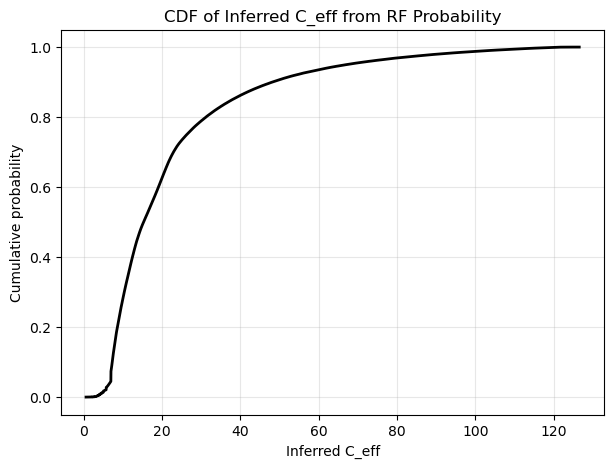

In [ ]:
from pathlib import Path
from pci_source_zones.inputs import read_raster

OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow")

# use the RF probability raster you created
rf_prob_path = OUT / "rf_random_source_probability_no_channels_Glt120.tif"
# rf_prob_path = OUT / "rf_random_source_probability.tif"  # use this if needed

rf_prob, _ = read_raster(rf_prob_path)

# control parameter for probability-to-Ceff conversion
k = 1.0

# avoid logit problems at P = 0 or P = 1
p = np.clip(rf_prob, 0.001, 0.999)

# logit(P)
logit_p = np.log(p / (1 - p))

# inferred effective C
Ceff = G - logit_p / k

# keep valid values only
Ceff_values = Ceff[np.isfinite(Ceff)]

# save Ceff raster
ceff_path = OUT / "Ceff_from_RF_probability.tif"
write_float_raster(ceff_path, Ceff.astype("float32"), profile)

print("saved Ceff raster:", ceff_path)
print("Ceff min/median/max:", np.nanmin(Ceff), np.nanmedian(Ceff), np.nanmax(Ceff))

# CDF
Ceff_sorted = np.sort(Ceff_values)
cdf = np.arange(1, len(Ceff_sorted) + 1) / len(Ceff_sorted)

plt.figure(figsize=(7, 5))
plt.plot(Ceff_sorted, cdf, color="black", linewidth=2)
plt.xlabel("Inferred C_eff")
plt.ylabel("Cumulative probability")
plt.title("CDF of Inferred C_eff from RF Probability")
plt.grid(True, alpha=0.3)
plt.show()

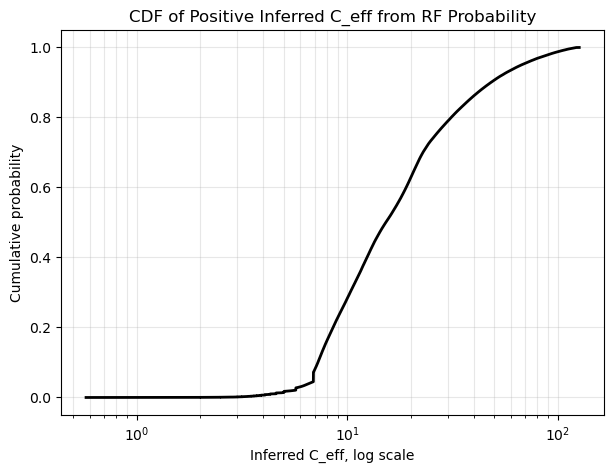

In [9]:
Ceff_pos = Ceff_values[Ceff_values > 0]

Ceff_sorted = np.sort(Ceff_pos)
cdf = np.arange(1, len(Ceff_sorted) + 1) / len(Ceff_sorted)

plt.figure(figsize=(7, 5))
plt.plot(Ceff_sorted, cdf, color="black", linewidth=2)
plt.xscale("log")
plt.xlabel("Inferred C_eff, log scale")
plt.ylabel("Cumulative probability")
plt.title("CDF of Positive Inferred C_eff from RF Probability")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 7. Polygon Train/Test Split

Training polygons are used for fitting and tuning. Test polygons stay held out until final evaluation.

In [53]:
polys = gpd.read_file(POLYGON_PATH)
if polys.crs != profile['crs']:
    polys = polys.to_crs(profile['crs'])

train_geom = polys.loc[polys[POLYGON_ID_FIELD].isin(TRAIN_POLY_IDS), 'geometry']
test_geom = polys.loc[polys[POLYGON_ID_FIELD].isin(TEST_POLY_IDS), 'geometry']

if train_geom.empty:
    raise ValueError(f'No train polygons found for ids: {TRAIN_POLY_IDS}')
if test_geom.empty:
    raise ValueError(f'No test polygons found for ids: {TEST_POLY_IDS}')

train_mask = geometry_mask(
    train_geom,
    out_shape=Y.shape,
    transform=profile['transform'],
    invert=True,
)
test_mask = geometry_mask(
    test_geom,
    out_shape=Y.shape,
    transform=profile['transform'],
    invert=True,
)

train_valid = valid & train_mask
test_valid = valid & test_mask

X_train = pd.DataFrame({name: arr[train_valid] for name, arr in features.items()})
y_train = Y[train_valid]
X_test = pd.DataFrame({name: arr[test_valid] for name, arr in features.items()})
y_test = Y[test_valid]

print('train polygon ids:', TRAIN_POLY_IDS)
print('test polygon ids:', TEST_POLY_IDS)
print_class_counts('polygon train', y_train)
print_class_counts('polygon test', y_test)

if len(np.unique(y_train)) < 2:
    raise ValueError('Training polygons have only one class. Add/change training polygons.')
if len(np.unique(y_test)) < 2:
    print('Warning: held-out test polygons have only one class; metrics will be limited.')

train polygon ids: [3]
test polygon ids: [4]
polygon train cells: 82476 positive: 10393 negative: 72083
polygon test cells: 34023 positive: 1623 negative: 32400


## 8. Tune Random Forest On Training Polygons Only

In [51]:
rf_params = {
    'n_estimators': [5, 10, 20, 30, 40, 50, 60, 70, 80, 100, 120, 150, 200, 300],
    'max_depth': [None, 5, 10, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample'],
}

SCORING = 'f1'
N_ITER = 3000
CV_FOLDS = 3

base_rf = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_params,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)
rf_tuned = search.best_estimator_

print(f'Best CV {SCORING} score: {search.best_score_:.4f}')
print('Best params:')
for key, value in search.best_params_.items():
    print(f'  {key}: {value}')

cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
cv_results[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']].head(10)

Fitting 3 folds for each of 3000 candidates, totalling 9000 fits
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=5; total time=   0.8s
[CV] END class_weight=balanced_subsample, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=10; total time=   0.9s
[CV] END class_weight=balanced_subsample, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=10; total time=   1.0s
[CV] END class_weight=balanced_subsample, max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=10; total time=   1.0s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=5; total time=   1.3s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=5; total time=   1.7s
[CV] END class_weight=balanced, max_depth=None, max_feat

KeyboardInterrupt: 

## 9. Evaluate Held-Out Polygons

In [16]:
test_pred = rf_tuned.predict(X_test)
test_prob = rf_tuned.predict_proba(X_test)[:, 1]

print('held-out polygon confusion matrix:')
print(confusion_matrix(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, zero_division=0))

eval_table = pd.DataFrame({
    'y_true': y_test,
    'prob_source': test_prob,
    'pred_source': test_pred,
})
eval_csv = OUT / 'heldout_polygon_predictions.csv'
eval_table.to_csv(eval_csv, index=False)
print('saved held-out predictions:', eval_csv)

held-out polygon confusion matrix:
[[26468  1762]
 [ 5503   301]]

              precision    recall  f1-score   support

           0       0.83      0.94      0.88     28230
           1       0.15      0.05      0.08      5804

    accuracy                           0.79     34034
   macro avg       0.49      0.49      0.48     34034
weighted avg       0.71      0.79      0.74     34034

saved held-out predictions: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/heldout_polygon_predictions.csv


## 10. Feature Importance

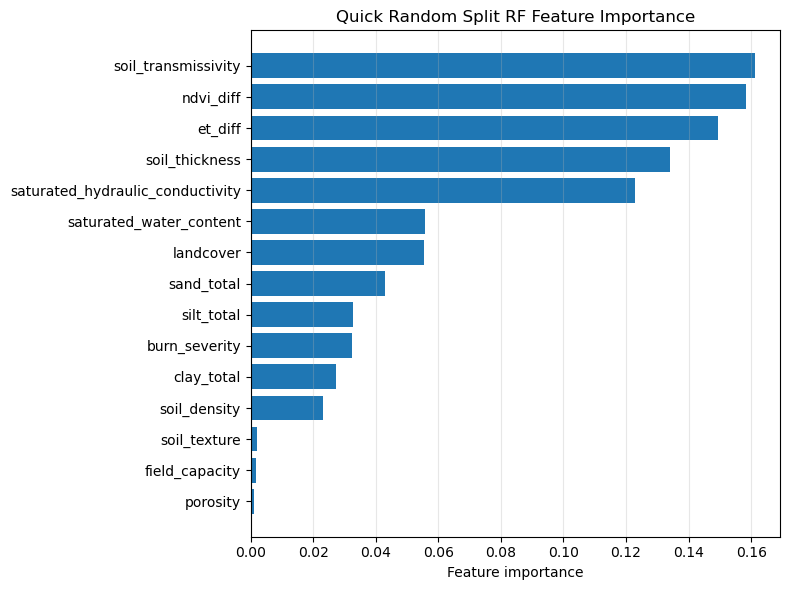

,feature,importance
10,soil_transmissivity,0.161167
14,ndvi_diff,0.158350
13,et_diff,0.149489
2,soil_thickness,0.133896
11,saturated_hydraulic_conductivity,0.122733
9,saturated_water_content,0.055598
12,landcover,0.055533
4,sand_total,0.042838
5,silt_total,0.032722
0,burn_severity,0.032516


In [54]:
# --------------------
# Feature importance for quick random split model
# --------------------
importance_random = pd.DataFrame({
    "feature": X_train_rand.columns,
    "importance": rf_random.feature_importances_,
}).sort_values("importance", ascending=False)

TOP_N = 15
plot_df = importance_random.head(TOP_N).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_xlabel("Feature importance")
ax.set_title("Quick Random Split RF Feature Importance")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

importance_random.head(TOP_N)

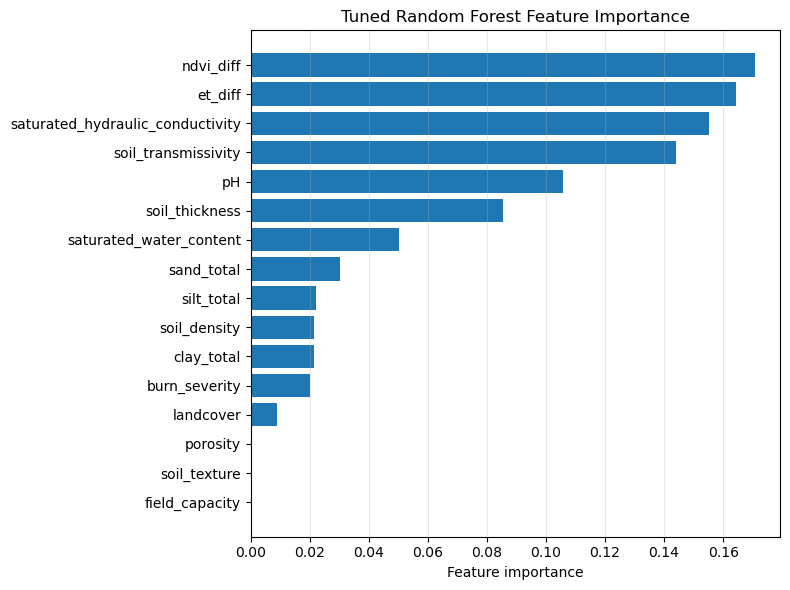

saved importance CSV: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/feature_importance_tuned.csv
saved importance plot: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/feature_importance_tuned.png


,feature,importance
15,ndvi_diff,0.170710
14,et_diff,0.164272
12,saturated_hydraulic_conductivity,0.155194
11,soil_transmissivity,0.144151
8,pH,0.105759
2,soil_thickness,0.085414
10,saturated_water_content,0.050360
4,sand_total,0.030067
5,silt_total,0.022258
3,soil_density,0.021515


In [20]:
importance_tuned = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_tuned.feature_importances_,
}).sort_values('importance', ascending=False)

importance_csv = OUT / 'feature_importance_tuned.csv'
importance_tuned.to_csv(importance_csv, index=False)

TOP_N = min(20, len(importance_tuned))
plot_df = importance_tuned.head(TOP_N).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df['feature'], plot_df['importance'])
ax.set_xlabel('Feature importance')
ax.set_title('Tuned Random Forest Feature Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
importance_png = OUT / 'feature_importance_tuned.png'
fig.savefig(importance_png, dpi=200)
plt.show()

print('saved importance CSV:', importance_csv)
print('saved importance plot:', importance_png)
importance_tuned

## 11. Partial Dependence


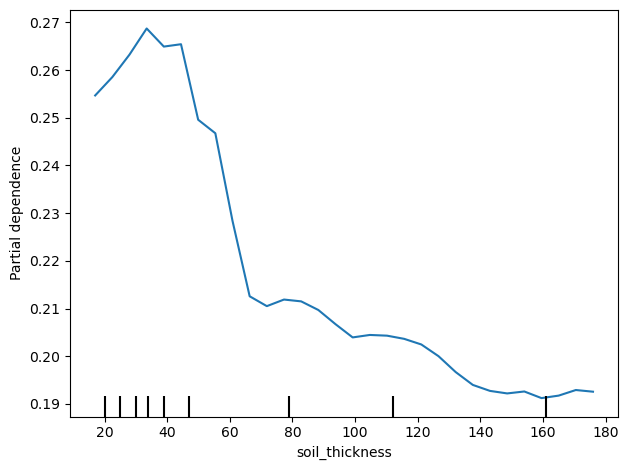

saved PDP plot: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/partial_dependence_soil_thickness_rf_random.png


In [55]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Choose features to plot
PDP_FEATURES = ["soil_thickness"]  # ["et_diff", "ndvi_diff", "soil_thickness"]

# Use the same X that matches the model you are plotting
X_PDP = X_train_rand   # for rf_random
MODEL_PDP = rf_random

pdp_features = [name for name in PDP_FEATURES if name in X_PDP.columns]

if not pdp_features:
    print("None of the requested PDP features are loaded:", PDP_FEATURES)
else:
    pdp_display = PartialDependenceDisplay.from_estimator(
        MODEL_PDP,
        X_PDP,
        features=pdp_features,
        target=1,
        grid_resolution=30,
    )

    plt.tight_layout()

    label = "_".join(pdp_features)
    pdp_png = OUT / f"partial_dependence_{label}_rf_random.png"

    plt.savefig(pdp_png, dpi=200)
    plt.show()

    print("saved PDP plot:", pdp_png)

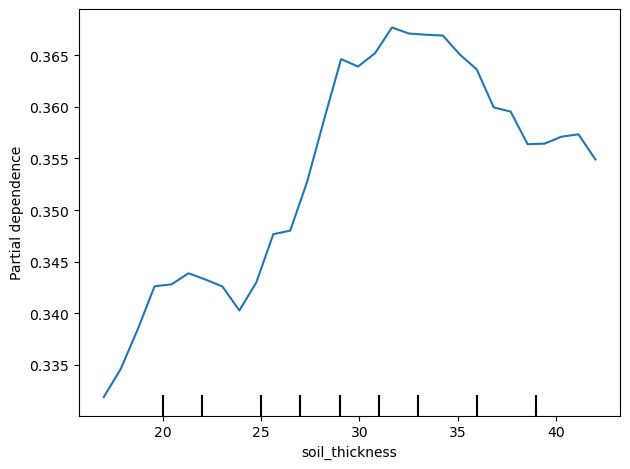

saved PDP plot: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/partial_dependence_soil_thickness.png


In [40]:
PDP_FEATURES = ['soil_thickness'] #['et_diff', 'ndvi_diff', 'soil_thickness']
pdp_features = [name for name in PDP_FEATURES if name in X_train.columns]

if not pdp_features:
    print('None of the requested PDP features are loaded:', PDP_FEATURES)
else:
    display = PartialDependenceDisplay.from_estimator(
        rf_random,
        X_train,
        features=pdp_features,
        target=1,
        grid_resolution=30,
    )
    plt.tight_layout()
    label = '_'.join(pdp_features)
    pdp_png = OUT / f'partial_dependence_{label}.png'
    plt.savefig(pdp_png, dpi=200)
    plt.show()
    print('saved PDP plot:', pdp_png)

## 12. Logistic Regression Relationship

This is an interpretable comparison model. Use it to discuss coefficient direction and relative standardized effect, not as a replacement for the tuned RF unless it performs better on the held-out polygon.

In [23]:
LOGIT_FEATURES = ['et_diff', 'ndvi_diff', 'soil_thickness']
selected_features = [name for name in LOGIT_FEATURES if name in X_train.columns]

if len(selected_features) < 1:
    print('No requested logistic features are loaded:', LOGIT_FEATURES)
else:
    logit = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=5000,
            random_state=RANDOM_SEED,
        )),
    ])

    logit.fit(X_train[selected_features], y_train)
    logit_pred = logit.predict(X_test[selected_features])

    print('logistic features:', selected_features)
    print(confusion_matrix(y_test, logit_pred))
    print(classification_report(y_test, logit_pred, zero_division=0))

    coef = pd.DataFrame({
        'feature': selected_features,
        'coef_standardized': logit.named_steps['model'].coef_[0],
    }).sort_values('coef_standardized', ascending=False)

    coef_csv = OUT / 'logistic_standardized_coefficients.csv'
    coef.to_csv(coef_csv, index=False)
    print('saved coefficients:', coef_csv)
    coef #coef  display(coef)

    equation_terms = [
        f"({row.coef_standardized:.3f})*z_{row.feature}"
        for row in coef.itertuples(index=False)
    ]
    intercept = float(logit.named_steps['model'].intercept_[0])
    print('Approximate standardized logistic form:')
    print('P(source) = 1 / (1 + exp(-X))')
    print('X = ' + f'{intercept:.3f} + ' + ' + '.join(equation_terms))


logistic features: ['et_diff', 'ndvi_diff', 'soil_thickness']
[[18314  9916]
 [ 4063  1741]]
              precision    recall  f1-score   support

           0       0.82      0.65      0.72     28230
           1       0.15      0.30      0.20      5804

    accuracy                           0.59     34034
   macro avg       0.48      0.47      0.46     34034
weighted avg       0.70      0.59      0.63     34034

saved coefficients: /mnt/c/Users/amehedi/Downloads/source_area_workflow/random_forest/logistic_standardized_coefficients.csv
Approximate standardized logistic form:
P(source) = 1 / (1 + exp(-X))
X = -0.008 + (0.035)*z_soil_thickness + (0.013)*z_et_diff + (-0.170)*z_ndvi_diff


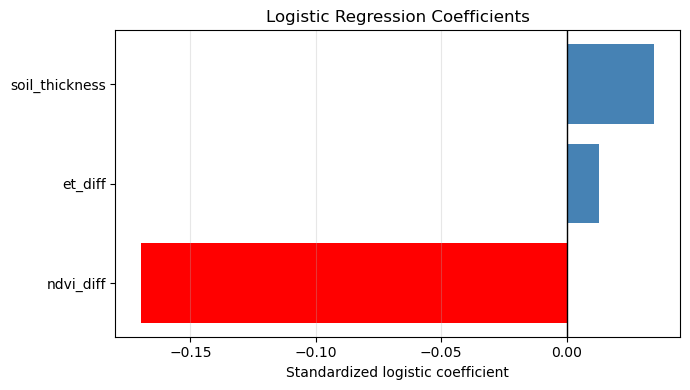

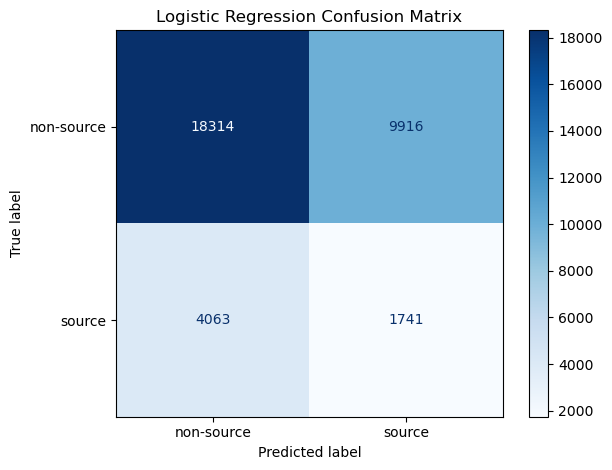

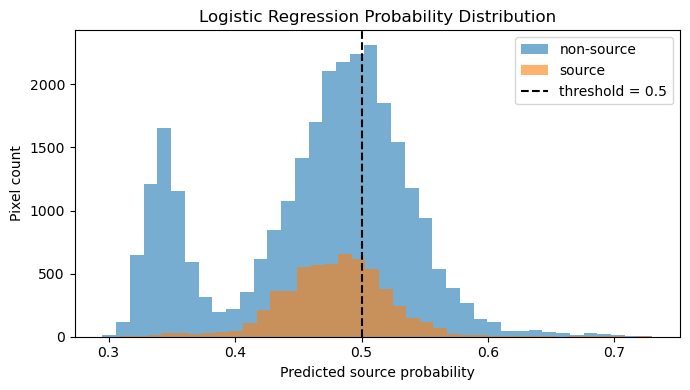

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --------------------
# 1. Coefficient bar plot
# --------------------
coef_plot = coef.sort_values("coef_standardized")

plt.figure(figsize=(7, 4))
colors = ["red" if v < 0 else "steelblue" for v in coef_plot["coef_standardized"]]

plt.barh(coef_plot["feature"], coef_plot["coef_standardized"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardized logistic coefficient")
plt.title("Logistic Regression Coefficients")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------
# 2. Confusion matrix plot
# --------------------
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logit_pred,
    display_labels=["non-source", "source"],
    cmap="Blues",
    values_format="d",
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

# --------------------
# 3. Predicted probability histogram
# --------------------
logit_prob = logit.predict_proba(X_test[selected_features])[:, 1]

plt.figure(figsize=(7, 4))
plt.hist(logit_prob[y_test == 0], bins=40, alpha=0.6, label="non-source")
plt.hist(logit_prob[y_test == 1], bins=40, alpha=0.6, label="source")
plt.axvline(0.5, color="black", linestyle="--", label="threshold = 0.5")
plt.xlabel("Predicted source probability")
plt.ylabel("Pixel count")
plt.title("Logistic Regression Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Predict Full Raster And Export


In [ ]:
X_full = pd.DataFrame({name: arr[valid] for name, arr in features.items()})
prob_values = rf_tuned.predict_proba(X_full)[:, 1].astype('float32')

prob_map = np.full(Y.shape, np.nan, dtype='float32')
prob_map[valid] = prob_values

class_map = np.full(Y.shape, TARGET_NODATA, dtype='uint8')
class_map[valid] = (prob_map[valid] >= PROB_THRESHOLD).astype('uint8')

prob_path = OUT / f'rf_tuned_source_probability_C{C_SOURCE}_lt_channel_C{C_CHANNEL}.tif'
class_path = OUT / f'rf_tuned_source_class_C{C_SOURCE}_lt_channel_C{C_CHANNEL}_p{str(PROB_THRESHOLD).replace(".", "p")}.tif'
write_float_raster(prob_path, prob_map, profile)
write_uint8_raster(class_path, class_map, profile, nodata=TARGET_NODATA)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.where(np.isfinite(Y_raw), Y, np.nan), cmap='gray')
axes[0].set_title('ML target')
im = axes[1].imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('RF source probability')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(np.where(class_map == TARGET_NODATA, np.nan, class_map), cmap='gray')
axes[2].set_title(f'RF class p >= {PROB_THRESHOLD}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
summary_png = OUT / 'rf_tuned_prediction_summary.png'
fig.savefig(summary_png, dpi=200)
plt.show()

print('saved probability raster:', prob_path)
print('saved class raster:', class_path)
print('saved summary plot:', summary_png)
print('predicted source cells:', int(np.sum(class_map == 1)))